# Exploratory Data Analysis

##### Importing Packages

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings

##### Loading Data

In [2]:
df = pd.read_csv('../data/interim/customer_churn_cleaned.csv')
df.head()

,CustomerID,Count,Country,State,City,Zip Code,Lat Long,Latitude,Longitude,Gender,...,Contract,Paperless Billing,Payment Method,Monthly Charges,Total Charges,Churn Label,Churn Value,Churn Score,CLTV,Churn Reason
0,3668-QPYBK,1,United States,California,Los Angeles,90003,"33.964131, -118.272783",33.964131,-118.272783,Male,...,Month-to-month,Yes,Mailed check,53.85,108.15,Yes,1,86,3239,Competitor made better offer
1,9237-HQITU,1,United States,California,Los Angeles,90005,"34.059281, -118.30742",34.059281,-118.307420,Female,...,Month-to-month,Yes,Electronic check,70.70,151.65,Yes,1,67,2701,Moved
2,9305-CDSKC,1,United States,California,Los Angeles,90006,"34.048013, -118.293953",34.048013,-118.293953,Female,...,Month-to-month,Yes,Electronic check,99.65,820.50,Yes,1,86,5372,Moved
3,7892-POOKP,1,United States,California,Los Angeles,90010,"34.062125, -118.315709",34.062125,-118.315709,Female,...,Month-to-month,Yes,Electronic check,104.80,3046.05,Yes,1,84,5003,Moved
4,0280-XJGEX,1,United States,California,Los Angeles,90015,"34.039224, -118.266293",34.039224,-118.266293,Male,...,Month-to-month,Yes,Bank transfer (automatic),103.70,5036.30,Yes,1,89,5340,Competitor had better devices


In [3]:
df.shape

(7043, 33)

##### Feature

In [4]:
TARGET = 'Churn Value'
id_cols = ['CustomerID']
metadata_cols = ['Count']
leakage_cols = ['Churn Label', 'Churn Reason', 'Churn Score']
business_cols = ['CLTV']

In [5]:
eda_df = df.copy()

In [6]:
model_features = eda_df.drop(
    columns=
    id_cols
    + metadata_cols
    + leakage_cols
)

In [7]:
model_features.columns

Index(['Country', 'State', 'City', 'Zip Code', 'Lat Long', 'Latitude',
       'Longitude', 'Gender', 'Senior Citizen', 'Partner', 'Dependents',
       'Tenure Months', 'Phone Service', 'Multiple Lines', 'Internet Service',
       'Online Security', 'Online Backup', 'Device Protection', 'Tech Support',
       'Streaming TV', 'Streaming Movies', 'Contract', 'Paperless Billing',
       'Payment Method', 'Monthly Charges', 'Total Charges', 'Churn Value',
       'CLTV'],
      dtype='object')

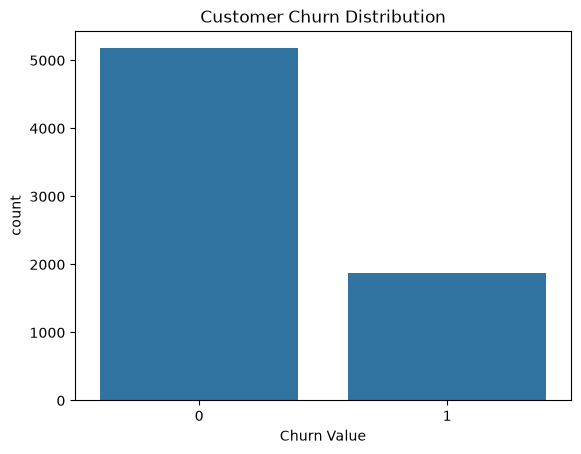

In [10]:
# As per data understanding notebook findings
# we are going to use stratified split 
# due to moderate imbalance in the target variable
sns.countplot(
    data=df,
    x=TARGET
)

plt.title(
    "Customer Churn Distribution"
)

plt.show()

In [14]:
features_df = df.drop(
    columns=
    id_cols
    + metadata_cols
    + leakage_cols
)
features_df.columns

Index(['Country', 'State', 'City', 'Zip Code', 'Lat Long', 'Latitude',
       'Longitude', 'Gender', 'Senior Citizen', 'Partner', 'Dependents',
       'Tenure Months', 'Phone Service', 'Multiple Lines', 'Internet Service',
       'Online Security', 'Online Backup', 'Device Protection', 'Tech Support',
       'Streaming TV', 'Streaming Movies', 'Contract', 'Paperless Billing',
       'Payment Method', 'Monthly Charges', 'Total Charges', 'Churn Value',
       'CLTV'],
      dtype='object')

In [12]:
X_temp = features_df.drop(columns=[TARGET],axis=1)

In [13]:
X_temp.head()

,Country,State,City,Zip Code,Lat Long,Latitude,Longitude,Gender,Senior Citizen,Partner,...,Device Protection,Tech Support,Streaming TV,Streaming Movies,Contract,Paperless Billing,Payment Method,Monthly Charges,Total Charges,CLTV
0,United States,California,Los Angeles,90003,"33.964131, -118.272783",33.964131,-118.272783,Male,No,No,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,3239
1,United States,California,Los Angeles,90005,"34.059281, -118.30742",34.059281,-118.307420,Female,No,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,2701
2,United States,California,Los Angeles,90006,"34.048013, -118.293953",34.048013,-118.293953,Female,No,No,...,Yes,No,Yes,Yes,Month-to-month,Yes,Electronic check,99.65,820.50,5372
3,United States,California,Los Angeles,90010,"34.062125, -118.315709",34.062125,-118.315709,Female,No,Yes,...,Yes,Yes,Yes,Yes,Month-to-month,Yes,Electronic check,104.80,3046.05,5003
4,United States,California,Los Angeles,90015,"34.039224, -118.266293",34.039224,-118.266293,Male,No,No,...,Yes,No,Yes,Yes,Month-to-month,Yes,Bank transfer (automatic),103.70,5036.30,5340


In [32]:
# Categorical columns
categorical_cols = X_temp.select_dtypes(include=['object']).columns.to_list()

# Numerical columns
numerical_cols = X_temp.select_dtypes(exclude=['object']).columns.to_list()

In [33]:
print(f"Categorical columns: {categorical_cols}")
print(f"Numerical columns: {numerical_cols}")

Categorical columns: ['Country', 'State', 'City', 'Lat Long', 'Gender', 'Senior Citizen', 'Partner', 'Dependents', 'Phone Service', 'Multiple Lines', 'Internet Service', 'Online Security', 'Online Backup', 'Device Protection', 'Tech Support', 'Streaming TV', 'Streaming Movies', 'Contract', 'Paperless Billing', 'Payment Method']
Numerical columns: ['Zip Code', 'Latitude', 'Longitude', 'Tenure Months', 'Monthly Charges', 'Total Charges', 'CLTV']


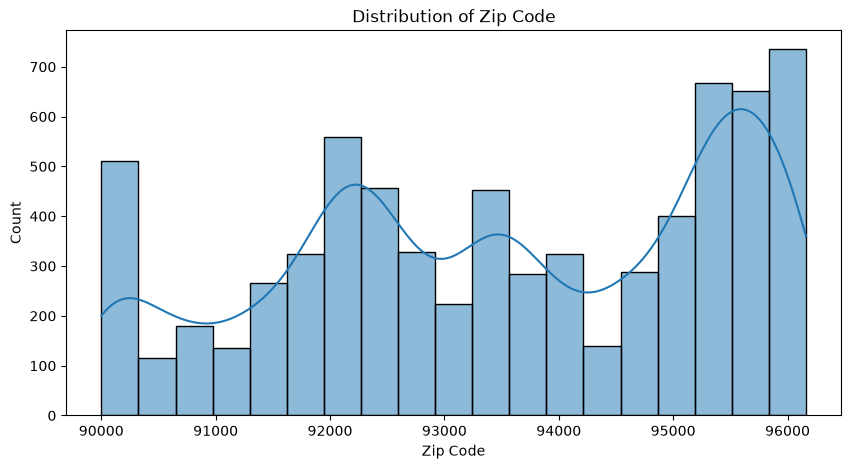

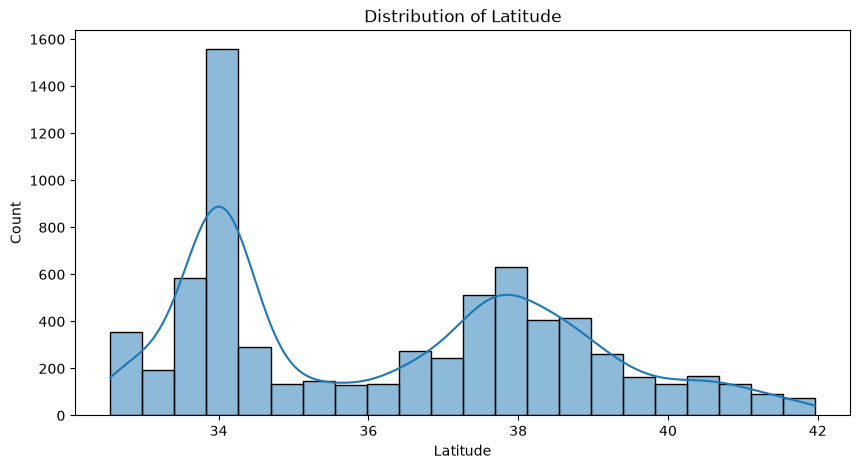

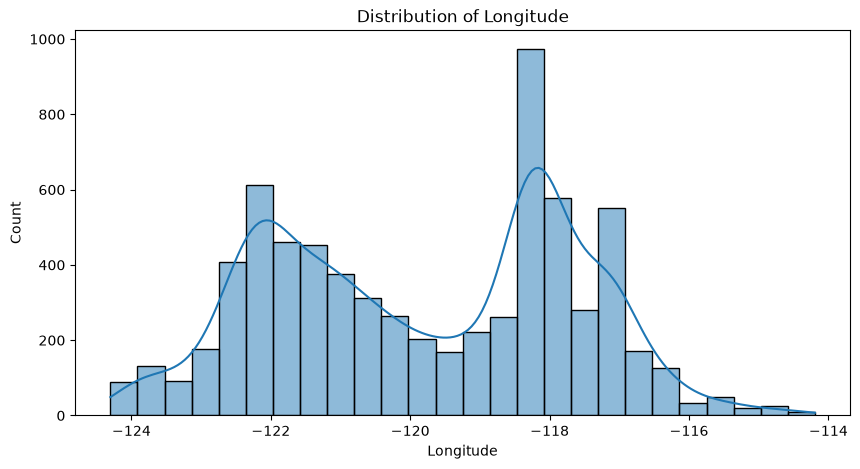

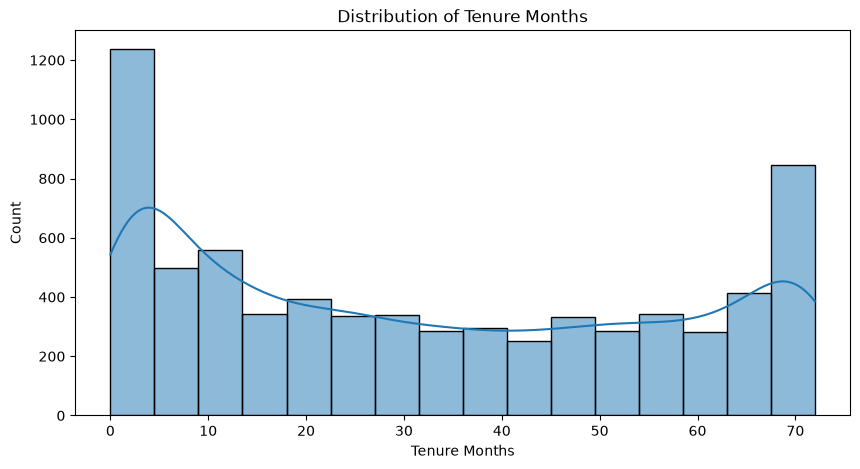

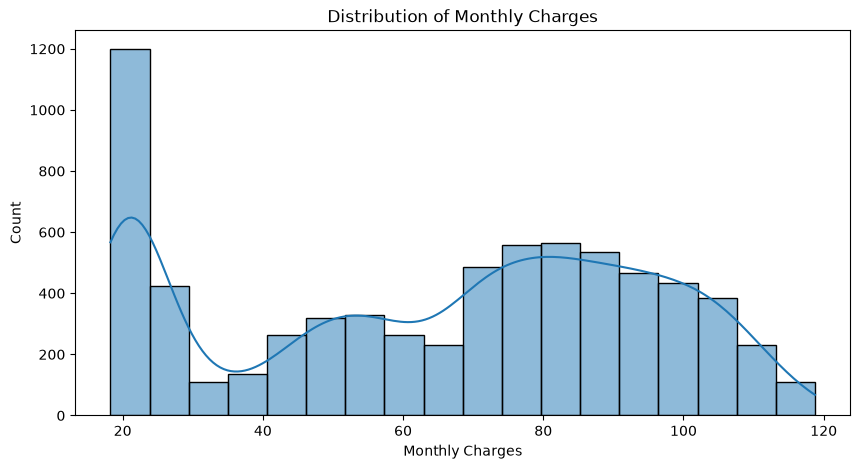

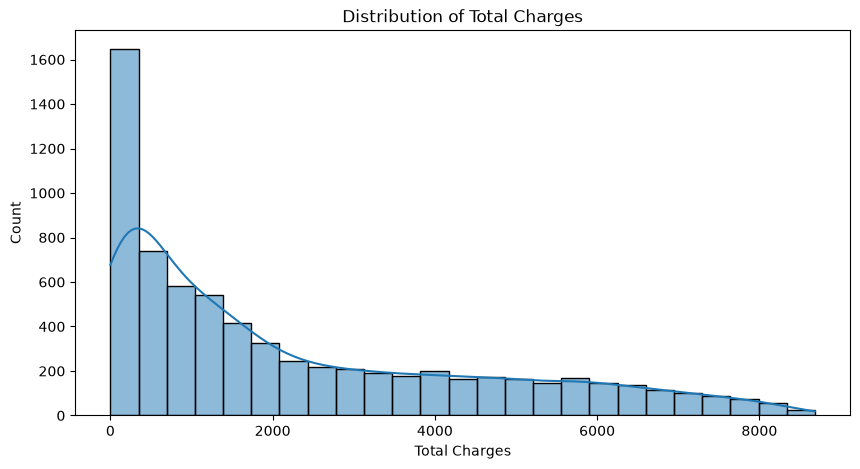

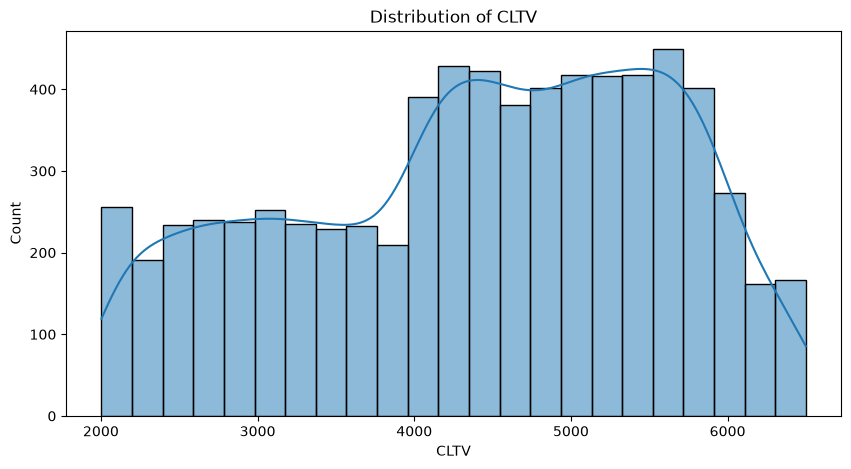

In [34]:
for col in numerical_cols:
    plt.figure(figsize=(10,5))

    sns.histplot(
        data = df,
        x = col,
        kde = True
    )

    plt.title(
        f"Distribution of {col}"
    )

    plt.show()

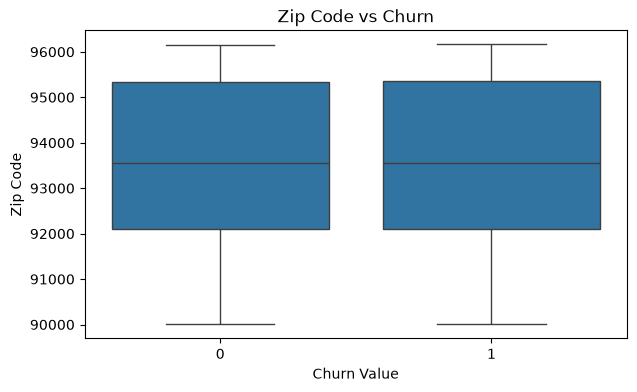

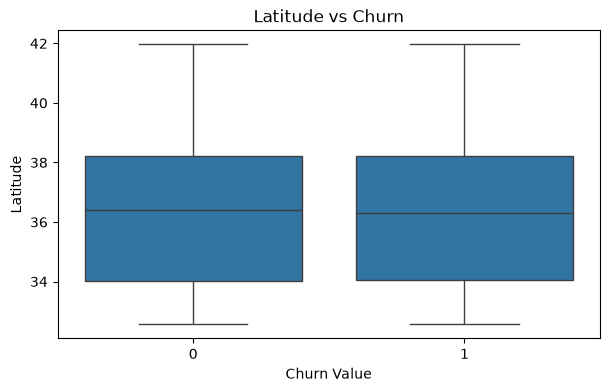

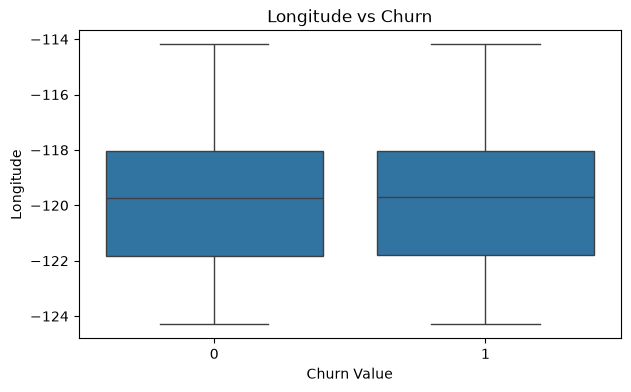

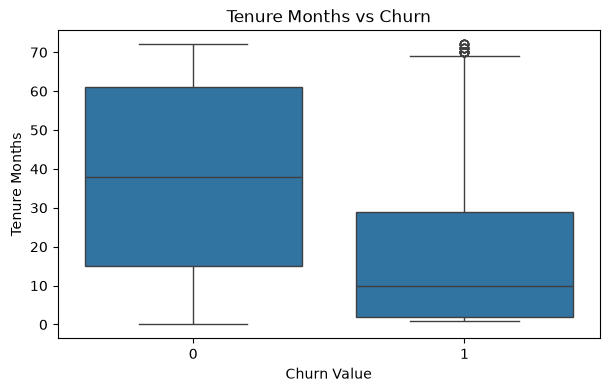

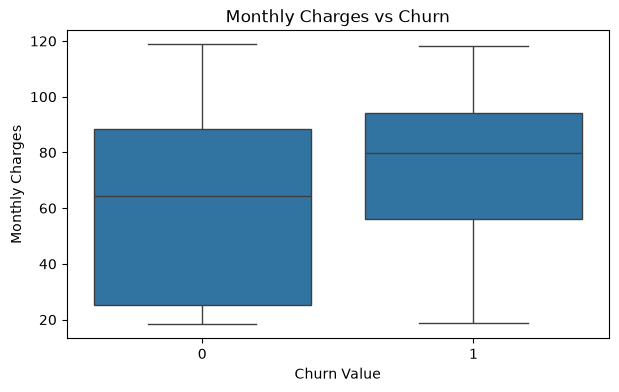

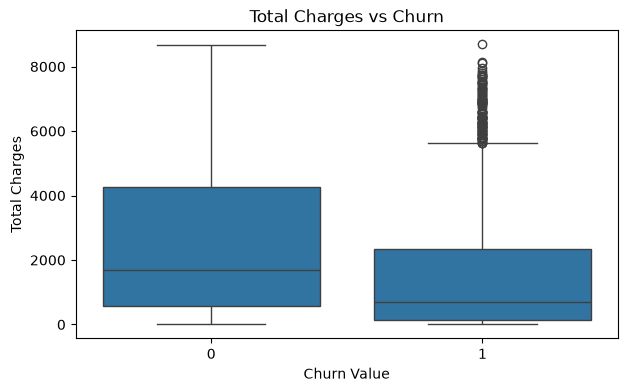

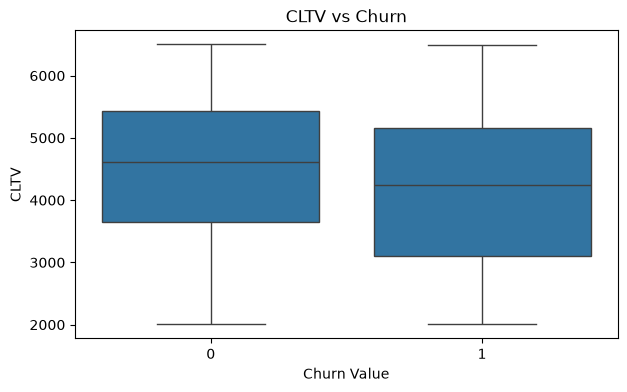

In [35]:
for col in numerical_cols:
    plt.figure(figsize = (7,4))

    sns.boxplot(
        data = df,
        x = TARGET,
        y = col
    )

    plt.title(
        f"{col} vs Churn"
    )

    plt.show()

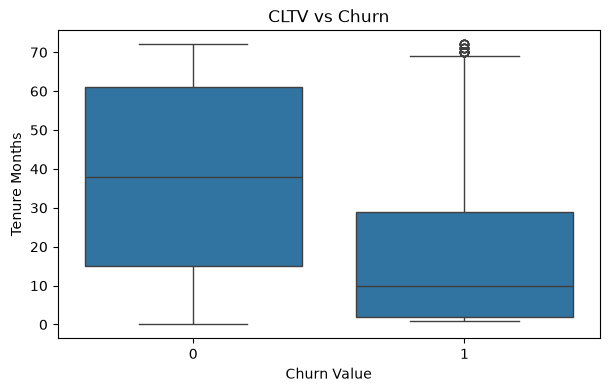

In [36]:
# We can see that the Churn customers generally have lower tenure months
plt.figure(figsize = (7,4))

sns.boxplot(
    data = df,
    x = TARGET,
    y = 'Tenure Months'
)

plt.title(
    f"{col} vs Churn"
)

plt.show()

In [37]:
for col in categorical_cols:
    print("\n", col)

    display(
        df[col].value_counts(normalize=True)*100
    )


 Country


Country
United States    100.0
Name: proportion, dtype: float64


 State


State
California    100.0
Name: proportion, dtype: float64


 City


...

Contract
Month-to-month    55.019168
Two year          24.066449
One year          20.914383
Name: proportion, dtype: float64


 Paperless Billing


Paperless Billing
Yes    59.221922
No     40.778078
Name: proportion, dtype: float64


 Payment Method


Payment Method
Electronic check             33.579441
Mailed check                 22.887974
Bank transfer (automatic)    21.922476
Credit card (automatic)      21.610109
Name: proportion, dtype: float64

In [38]:
for col in categorical_cols:

    churn_rate = (
        df.groupby(col)[TARGET]
        .mean()
        .sort_values(
            ascending = False
        )
    )

    print("\n", col)
    display(churn_rate)


 Country


Country
United States    0.26537
Name: Churn Value, dtype: float64


 State


State
California    0.26537
Name: Churn Value, dtype: float64


 City


...

Contract
Month-to-month    0.427097
One year          0.112695
Two year          0.028319
Name: Churn Value, dtype: float64


 Paperless Billing


Paperless Billing
Yes    0.335651
No     0.163301
Name: Churn Value, dtype: float64


 Payment Method


Payment Method
Electronic check             0.452854
Mailed check                 0.191067
Bank transfer (automatic)    0.167098
Credit card (automatic)      0.152431
Name: Churn Value, dtype: float64

- Custopmers with monthly contracts churn significantly more.

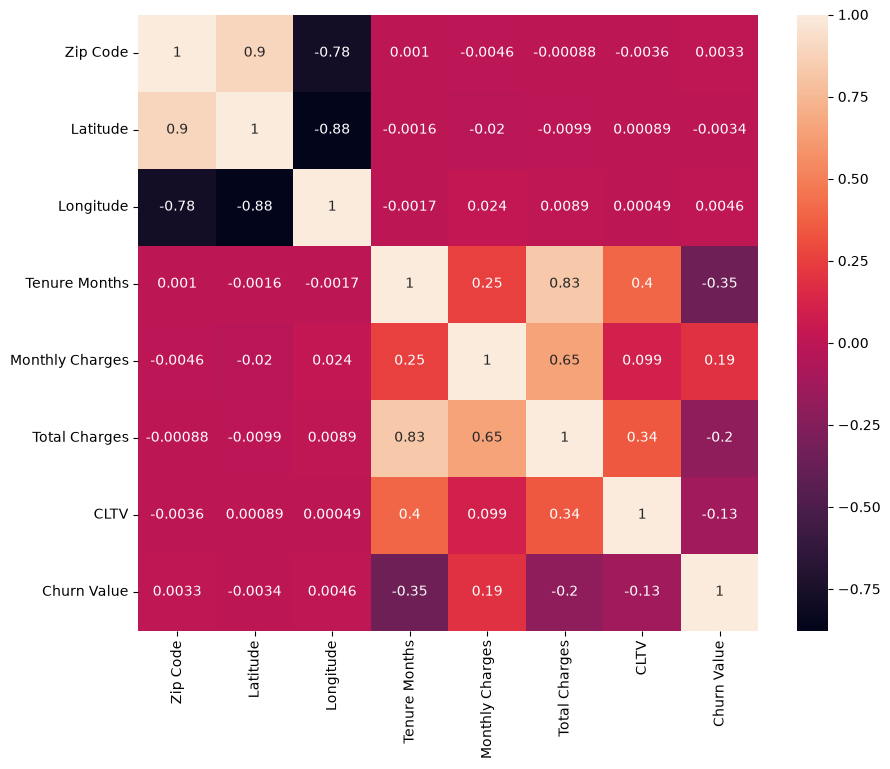

In [40]:
plt.figure(figsize = (10,8))

sns.heatmap(
    df[numerical_cols + [TARGET]]
    .corr(),
    annot = True
)

plt.show()

- Tenure months have moderate negative correlaiton -> Tenure increases then Churn probability decreases
- Monthly charges has a positive correlaiton -> Monthly charges increases then Churn probability increases
- Total Charges has a negative correlaiton -> Total charges increases the Churn probability decreases, because total charges is related to tenure.

- Tenure months vs Total Charges has a correlation of 0.83 very high, that is tenure months increases then total charges increases. This is an example of duplicate information. because they carry similar information. (Total Charges ≈ Tenure Months × Monthly Charges). This is called multicollinearity meaning Meaning features overlap.
- Impact:
    - Linear models:
    Logistic Regression: Can cause unstable coefficients.
    
    - Tree models:
    Random Forest / XGBoost: Usually handle it better.

Columns with almost 0 collinearity
- Zip Code
- Latitude
- Longitude
- Lat Long
- Country
- State

## EDA Conclusions

Important predictors discovered:
- Tenure Months
- Contract
- Internet Service
- Tech Support
- Monthly Charges

Feature decisions:
- Remove CustomerID
- Remove Count
- Remove churn leakage columns
- Remove multicollinearity columns
- Remove almost 0 collinearity columns

Modeling decisions:
- Stratified train-test split
- Compare models using Recall, F1, ROC-AUC
- Experiment with CLTV separately